In [1]:
# Copyright 2026 International Business Machines

# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at

#  http://www.apache.org/licenses/LICENSE-2.0

# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Terrakit: Labels to dataset pipeline for Salt Marsh dataset preparation

This notebook demonstrates generating a ML-ready dataset from a collection of salt marsh labels using [TerraKit](https://torchgeo.org/terrakit/), an open source python library purpose built for generating ML-ready geospatial datasets. 

TODO: Add a sentence about how the labels were created, where they are stored and how/why they need to be downloaded.

TerraKit extracts date and location information from each label file. This information is then used by TerraKit to download the corresponding satellite image from the data source requested, which in this case is [Sentinel-2 Level-2A](https://docs.sentinel-hub.com/api/latest/data/sentinel-2-l2a/). The generated dataset will consist of data/label pairs that have been chipped (split) into 256x256 images and is ready to use by TerraTorch to train a geospatial foundation model. 


## 0. Setup

### 0.1 Check Python Version

It's recommended that you run this notebook using Python 3.12.

In [4]:
!python --version

Python 3.13.13


### 0.2 Install and Import Dependencies

If running locally, ensure you have the necessary packages installed. This assumes you're in the project root directory. 

Once installed, import dependencies.

In [5]:
# Uncomment if you need to install dependencies
# cd ../..
# !pip install uv
# !uv sync

In [1]:
import logging
import os

# Import TerraKit
import terrakit 

# Include helper script
from create_salt_marsh_labels_csv import marsh_labels_to_csv

# Set LOGLEVEL to info for less verbose logging
os.environ["LOGLEVEL"] = "WARNING"

# Suppress rasterio warning messages. These are safe to ignore for now.
logging.getLogger('rasterio').setLevel(logging.ERROR)


Check you are using the latest version of TerraKit. This notebook has been tested with 0.1.8.post1.

In [2]:
!terrakit --version

terrakit 0.1.8.post1


### 0.3 Download Salt Marsh Labels

<div class="alert alert-block alert-failure">
TODO: Add instructions on downloading labels.
</div>

## 1. Process labels
The first step in the TerraKit dataset curation pipeline is processing the labels. 

Use `process_labels()` to generate the two DataFrame, where the first contains bound box and temporal information for all of the geospatial locations identified in the labels files, and the second containing the label geometries. Each DataFrame is also saved as a .shp file in the working directory.

The `process_labels` function takes the following arguments:
- `labels_folder`: The directory containing the labels.
- `dataset_name`: The name of the dataset.
- `working_dir`: The working directory where the processed labels will be saved.
- `label_type`: The type of labels, either "raster" or "vector".
- `datetime_info`: The format of the datetime information in the labels.


The `labels_folder` should also include a `metadata.csv` which will contain temporal information about each label file. As the salt marsh label files have a unique format, we will generate this `metadata.csv` file by extracting the temporal information from each label filename.



In [3]:
# Set a working directory, a dataset name and a directory where some labels can be found
DATASET_NAME = "s2_saltmarsh_extent"
WORKING_DIR = f"./tmp/{DATASET_NAME}" # This is where your new dataset will be saved to.
LABELS_FOLDER = "./labels"

In [4]:
# This helper function will extract the temporal information from the label filename and save it in a csv file in the.
# marsh_labels_to_csv(LABELS_FOLDER) # TODO: Update as no month in file name
!echo "filename,date\northo_RGBN_dee_2024_res_10m_cleaned_lab.tif,2024-06-15" > labels/metadata.csv

In [8]:
# Process the labels by providing a labels folder, working directory and dataset name. 
# The resulting shapefiles will be saved in the working directory.
labels_gdf, grouped_bbox_gdf = terrakit.process_labels(
    labels_folder=LABELS_FOLDER,
    dataset_name=DATASET_NAME,
    working_dir=WORKING_DIR,
    label_type="raster", # Can be raster or vector labels
    datetime_info="csv" # Datetime information is provided in csv format
)

2026-06-10 18:22:41 [INFO    ] Processing labels with arguments: {'labels_folder': './labels', 'dataset_name': 's2_saltmarsh_extent', 'working_dir': './tmp/s2_saltmarsh_extent', 'active': True, 'label_type': 'raster', 'datetime_info': 'csv'} (labels.py:617)
2026-06-10 18:22:41 [INFO    ] Creating working directory: tmp/s2_saltmarsh_extent (pipeline_model.py:68)
2026-06-10 18:22:41 [INFO    ] Processing with parent arguments: dataset_name='s2_saltmarsh_extent' working_dir=PosixPath('tmp/s2_saltmarsh_extent') (pipeline_model.py:104)
2026-06-10 18:22:41 [INFO    ] Processing labels with arguments: labels_folder=PosixPath('labels') active=True label_type='raster' datetime_info='csv' (labels.py:569)
2026-06-10 18:22:41 [INFO    ] Setting datetime to 2024-06-15 and label class to 1 for ortho_RGBN_dee_2024_res_10m_cleaned_lab.tif. (labels.py:336)
2026-06-10 18:22:41 [INFO    ] Successfully processed ./labels/ortho_RGBN_dee_2024_res_10m_cleaned_lab.tif (labels.py:343)
2026-06-10 18:22:41 [INFO

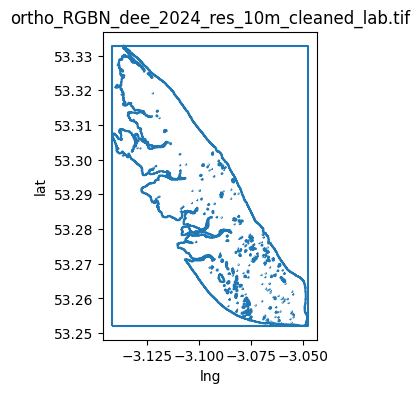

In [9]:
# Plot the process labels and bboxes to confirm they appear as expected.
# This helps to validate that the label geometries and bounding boxes have been extracted correctly.
# Here you can also see the bounding boxes which will be used by `download_data()` to download data for in the next step.
terrakit.plotting.plot_label_dataframes(labels_gdf, grouped_bbox_gdf)

## 2. Download the data

Once labels have been processed, next up in the TerraKit pipeline is downloading the data.

Use `download_data()` to download data from a set of data connectors for a time and location specified by the shapefiles saved by the process_labels pipeline step. Terrakit assumes that the shapefiles are in the working directory (which is where the process_labels pipeline step saves them to).

TerraKit allows you to request data is downloaded from any number of available data connectors, enabling you to download data from multiple sources in a single step. Here we download data solely from the S2L2A collection using the Sentinel-AWS data connector. This is the only data connector that does not require authentication, making it super simple to use.

In [10]:
config = {
    "download": {
        "data_sources": [
            {
                "data_connector": "sentinel_aws",
                "collection_name": "sentinel-2-l2a",
                "bands": ["blue", "green", "red", "nir", "nir08",],
            },
        ],
        "date_allowance": {"pre_days": 30, "post_days": 30}, # Define how long before and after the date specified in the shapefiles.
        "transform": {
            "scale_data_xarray": False,
            "impute_nans": False,
            "reproject": False,
        },
        "max_cloud_cover": 80, # Set the maximum perecent cloud cover allowed for the data to be downloaded.
        },
    }

queried_data = terrakit.download_data(
    dataset_name=DATASET_NAME,
    working_dir=WORKING_DIR,
    data_sources=config["download"]["data_sources"],
    date_allowance=config["download"]["date_allowance"],
    transform=config["download"]["transform"],
    max_cloud_cover=config["download"]["max_cloud_cover"],
    keep_files=True, # Set to True to keep any downloaded files that were created ahead of any transformations.
)

2026-06-10 18:22:43 [INFO    ] Processing download_data with arguments: {'data_sources': [{'data_connector': 'sentinel_aws', 'collection_name': 'sentinel-2-l2a', 'bands': ['blue', 'green', 'red', 'nir', 'nir08']}], 'date_allowance': {'pre_days': 30, 'post_days': 30}, 'transform': {'scale_data_xarray': False, 'impute_nans': False, 'reproject': False}, 'dataset_name': 's2_saltmarsh_extent', 'working_dir': './tmp/s2_saltmarsh_extent', 'active': True, 'max_cloud_cover': 80, 'datetime_bbox_shp_file': './tmp/terrakit_curated_dataset_all_bboxes.shp', 'labels_shp_file': './tmp/terrakit_curated_dataset_labels.shp', 'keep_files': True, 'set_no_data': False} (download_data.py:658)
2026-06-10 18:22:43 [INFO    ] Processing with parent arguments: dataset_name='s2_saltmarsh_extent' working_dir=PosixPath('tmp/s2_saltmarsh_extent') (pipeline_model.py:104)
2026-06-10 18:22:43 [INFO    ] Processing download_data with arguments: {'pipeline_model': PipelineModel(dataset_name='s2_saltmarsh_extent', working

[########################################] | 100% Completed | 11.72 s


2026-06-10 18:23:00 [INFO    ] Saving cloud optimized geotiff to tmp/s2_saltmarsh_extent/sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17.tif (geodata_utils.py:493)
2026-06-10 18:23:01 [INFO    ] Set band descriptions: ['blue', 'green', 'red', 'nir', 'nir08'] (geodata_utils.py:542)
2026-06-10 18:23:01 [INFO    ] Saving cloud optimized geotiff to tmp/s2_saltmarsh_extent/sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17.tif (geodata_utils.py:493)
2026-06-10 18:23:03 [INFO    ] Set band descriptions: ['blue', 'green', 'red', 'nir', 'nir08'] (geodata_utils.py:542)
2026-06-10 18:23:03 [INFO    ] Queried data: ['tmp/s2_saltmarsh_extent/sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17.tif']
----
 (download_data.py:389)
2026-06-10 18:23:03 [INFO    ] Rasterizing vectors to the queried data (download_data.py:409)
2026-06-10 18:23:03 [INFO    ] Label classes being used: [1] (download_data.py:414)
2026-06-10 18:23:03 [INFO    ] Writing to tmp/s2_saltmarsh_extent/sentinel_aws_sentinel-2-l2a_tile_0_1_2

### 2.2: Inspect the data
Use `terrakit.plot_tiles_and_label_pair()` to inspect the downloaded tiles and corresponding labels.

2026-06-10 18:23:22 [WARNING ] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.0]. (image.py:661)


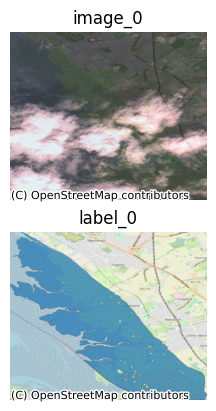

Legend
image_0: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17.tif, label_0: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_label.tif
---


In [11]:
terrakit.plotting.plot_tiles_and_label_pair(
    queried_data, bands=["red", "green", "blue"], scale = 2
)

## 3. Chip the data
Now that the tiled data has been downloaded, let's chip it accordingly.

### 3.1: Chip the data and label pairs
Use `chip_and_label_data()` to chip (split) the data and label pairs into 256x256 samples. The output will be saved in the `WORKING_DIR` with the specified `chip_suffix` and `chip_label_suffix`. 

In [12]:
res = terrakit.chip_and_label_data(
    dataset_name=DATASET_NAME,
    working_dir=WORKING_DIR,
    queried_data=queried_data, # data to chip (returned from download_data())
    sample_dim=256, # chip dimensions (256x256)
    data_suffix=".tif", # data file suffix (default: ".tif")
    label_suffix="_label.tif", # label file suffix (default: "_label.tif")
    chip_suffix="_chip.tif", # output S2 chip suffix
    chip_label_suffix="_chip_lab.tif" # Output label chip suffix
)

2026-06-10 18:23:29 [INFO    ] Processing labels with arguments: {'dataset_name': 's2_saltmarsh_extent', 'working_dir': './tmp/s2_saltmarsh_extent', 'active': True, 'data_suffix': '.tif', 'label_suffix': '_label.tif', 'chip_suffix': '_chip.tif', 'chip_label_suffix': '_chip_lab.tif', 'sample_dim': 256, 'queried_data': ['tmp/s2_saltmarsh_extent/sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17.tif'], 'keep_files': True, 'match_suffix': True, 'stats': True} (tiling.py:493)
2026-06-10 18:23:29 [INFO    ] Processing with parent arguments: dataset_name='s2_saltmarsh_extent' working_dir=PosixPath('tmp/s2_saltmarsh_extent') (pipeline_model.py:104)
2026-06-10 18:23:29 [INFO    ] Chipping data with arguments: active=True data_suffix='.tif' label_suffix='_label.tif' chip_suffix='_chip.tif' chip_label_suffix='_chip_lab.tif' sample_dim=256 queried_data=['tmp/s2_saltmarsh_extent/sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17.tif'] keep_files=True match_suffix=True (tiling.py:439)
2026-06-10 18:23:29 

Reloading chip and label


  0%|          | 0/1 [00:00<?, ?it/s]2026-06-10 18:23:29 [INFO    ] .tif (tiling.py:287)
2026-06-10 18:23:29 [INFO    ] tmp/s2_saltmarsh_extent/sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17.tif (tiling.py:288)
2026-06-10 18:23:29 [INFO    ] tmp/s2_saltmarsh_extent/sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17 (tiling.py:289)
2026-06-10 18:23:29 [INFO    ] tmp/s2_saltmarsh_extent/sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_label.tif (tiling.py:290)
2026-06-10 18:23:29 [INFO    ] tmp/s2_saltmarsh_extent/sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17 (tiling.py:291)
2026-06-10 18:23:29 [INFO    ] Chipping data: tmp/s2_saltmarsh_extent/sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17.tif (tiling.py:298)
2026-06-10 18:23:29 [INFO    ] Chipping label data: tmp/s2_saltmarsh_extent/sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_label.tif (tiling.py:329)
100%|██████████| 1/1 [00:00<00:00, 10.19it/s]
2026-06-10 18:23:29 [INFO    ] finished chipping ['tmp/s2_saltmarsh_extent/sentinel_aws

### 3.2 Check the results
Use `plot_chip_and_label_pairs` to check the chip and label pairs look as expected.

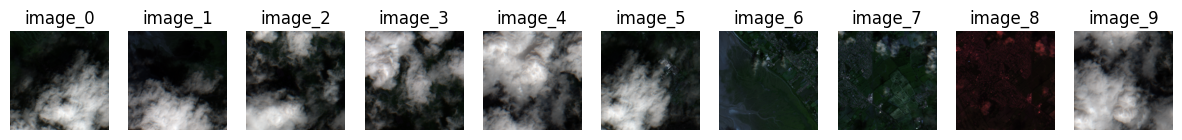

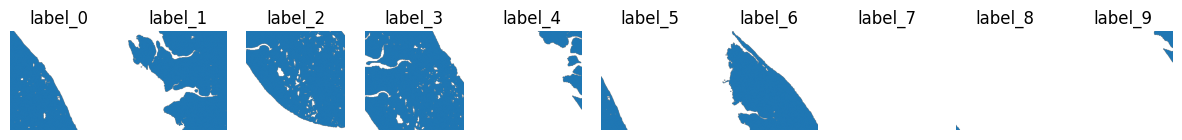

Legend
image_0: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_5_chip.tif
image_1: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_1_chip.tif
image_2: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_7_chip.tif
image_3: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_6_chip.tif
image_4: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_2_chip.tif
image_5: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_9_chip.tif
image_6: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_0_chip.tif
image_7: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_8_chip.tif
image_8: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_4_chip.tif
image_9: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_3_chip.tif
---
label_0: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_5_chip_lab.tif
label_1: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_1_chip_lab.tif
label_2: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_7_chip_lab.tif
label_3: sentinel_aws_sentinel-2-l2a_tile_0_1_2024-06-17_6_chip_lab.tif
label_4: sentinel_aws

In [ ]:
terrakit.plotting.plot_chip_and_label_pairs(
    res, bands=["red", "green", "blue"], samples=10,
    chip_suffix="_chip.tif",
    chip_label_suffix="_chip_lab.tif",
)

## 4. Next steps
Congratulations! You have successfully created an ML-ready dataset for training a salt marsh extent model using S2 data. Next steps is to see how well this dataset does at training a model following the steps in the Fine Tuning with Terramind notebook. See if you can improve the model performance by using a multi-modal data by adding another data connector to `download_data()`.

<div>
TODO: Part 1: A single label file. Add band verification. Part 2: Many labels. Add data provence review.
</div>

<!--
 Copyright (c) 2026 Copyright 2024 IBM Corp
 
 This software is released under the MIT License.
 https://opensource.org/licenses/MIT
-->

